# Tariff Share Time Series Analysis

**Description:** This notebook examines trends in industry level tariff share and import value from 2012 - 2025 to identify key drivers of trade shifts across major import industries.

**Dataset(s):** The excel files in the "tariff_database" folder and the "custom_value_2019_2025" excel file were both sourced from data.gov

### Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Functions

In [2]:
#assign industry to codes based off of hts coding (removed 98 and 99 as they were special provisions)
industry = [
    (1, 5, "Animal Products"),
    (6, 14, "Vegetable Products"),
    (15, 15, "Animal or Vegetable Fats and Oils"),
    (16, 24, "Prepared Foodstuffs; Beverages; Tobacco"),
    (25, 27, "Mineral Products"),
    (28, 38, "Chemical Products"),
    (39, 40, "Plastics and Rubber"),
    (41, 43, "Raw Hides, Skins, Leather, and Furs"),
    (44, 46, "Wood and Wood Products"),
    (47, 49, "Pulp, Paper, and Printed Materials"),
    (50, 63, "Textiles and Textile Articles"),
    (64, 67, "Footwear, Headgear, and Umbrellas"),
    (68, 70, "Stone, Cement, Ceramic, and Glass Products"),
    (71, 71, "Precious Stones and Metals"),
    (72, 83, "Base Metals and Articles of Base Metal"),
    (84, 85, "Machinery and Electrical Equipment"),
    (86, 89, "Transportation Equipment"),
    (90, 92, "Optical, Medical, and Musical Instruments"),
    (93, 93, "Arms and Ammunition"),
    (94, 96, "Miscellaneous Manufactured Articles"),
    (97, 97, "Works of Art and Antiques")
]

#add industry column to df
def get_industry(ch):
    for start, end, name in industry:
        if start <= ch <= end:
            return name
    return None

#load and clean tariff data
def load_tariff_data(tariff_file):
    df = pd.read_excel(tariff_file, dtype={"hts8": str})

    #convert hts8 to hts2 to get the chapter numbers
    df["hts8"] = df["hts8"].str.zfill(8)
    df["chapter"] = pd.to_numeric(df["hts8"].str[:2], errors="coerce")
    df = df.dropna(subset=["chapter"])
    df["chapter"] = df["chapter"].astype(int)

    #apply get_industry to associate industry to chapter
    df["industry"] = df["chapter"].apply(get_industry)

    #build tariff rate column from the mfn_ad_val_rate and remove any placeholder values
    df["tariff_rate"] = pd.to_numeric(df["mfn_ad_val_rate"], errors="coerce")
    df.loc[df["tariff_rate"] > 9999, "tariff_rate"] = np.nan

    #create final tariff dataframe
    tariff_df = df[["chapter", "hts8", "brief_description", "industry", "tariff_rate"]].copy()
    return tariff_df

#average tariffs by chapter
def summarize_tariffs_by_chapter(tariff_df):
    chapter_tariffs = (
        tariff_df
        .groupby(["chapter", "industry"], as_index=False)["tariff_rate"]
        .mean()
    )
    return chapter_tariffs

#load and clean trade data
def load_trade_data(trade_file, year, sheet_name=1, header_row=0):
    trade_df = pd.read_excel(trade_file, sheet_name=sheet_name, header=header_row)

    #clean column names
    trade_df.columns = (
        trade_df.columns.astype(str)
        .str.strip()
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
    )

    #convert needed columns
    trade_df["HTS Number"] = pd.to_numeric(trade_df["HTS Number"], errors="coerce")
    trade_df["Year"] = pd.to_numeric(trade_df["Year"], errors="coerce")
    trade_df["General Customs Value"] = pd.to_numeric(
        trade_df["General Customs Value"], errors="coerce"
    )

    #drop rows with na
    trade_df = trade_df.dropna(subset=["HTS Number", "Year"])

    #convert types to integers
    trade_df["HTS Number"] = trade_df["HTS Number"].astype(int)
    trade_df["Year"] = trade_df["Year"].astype(int)

    #filter to the requested year
    trade_df = trade_df[trade_df["Year"] == year].copy()

    #rename columns
    trade_df = trade_df.rename(columns={
        "HTS Number": "chapter",
        "General Customs Value": "import_value",
        "Year": "year"
    })

    #keep only needed columns
    trade_df = trade_df[["chapter", "import_value", "year"]].copy()

    return trade_df

#merge tariff and trade data and calculate tariff amount
def merge_tariff_and_trade(chapter_tariffs, trade_df):
    chapter_summary = chapter_tariffs.merge(
        trade_df[["chapter", "import_value", "year"]],
        on="chapter",
        how="left"
    )

    chapter_summary["tariff_amount"] = (
        chapter_summary["tariff_rate"] * chapter_summary["import_value"]
    )

    return chapter_summary

#combine functions to build the summary per year
def build_chapter_summary(year, trade_file):
    
    #load tariff file for that year
    tariff_file = f"../data/tariff_database/tariff_database_{year}.xlsx"
    tariff_df = load_tariff_data(tariff_file)
    
    #summarize tariffs by chapter
    chapter_tariffs = summarize_tariffs_by_chapter(tariff_df)
    
    #load trade data for that year
    trade_df = load_trade_data(trade_file, year)
    
    #merge
    chapter_summary = merge_tariff_and_trade(chapter_tariffs, trade_df)
    
    return chapter_summary

#combine years to build time series
def build_time_series(years, trade_file):
    
    all_years = []
    
    for y in years:
        summary = build_chapter_summary(y, trade_file)
        all_years.append(summary)
    
    time_series_df = pd.concat(all_years, ignore_index=True)
    
    return time_series_df

### Implement Functions

In [3]:
trade_file = '../data/customs_value_2012_2025.xlsx'
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
time_series_df = build_time_series(years, trade_file)

### Visualization

##### Tariff Amount by Industry (2012 - 2025)

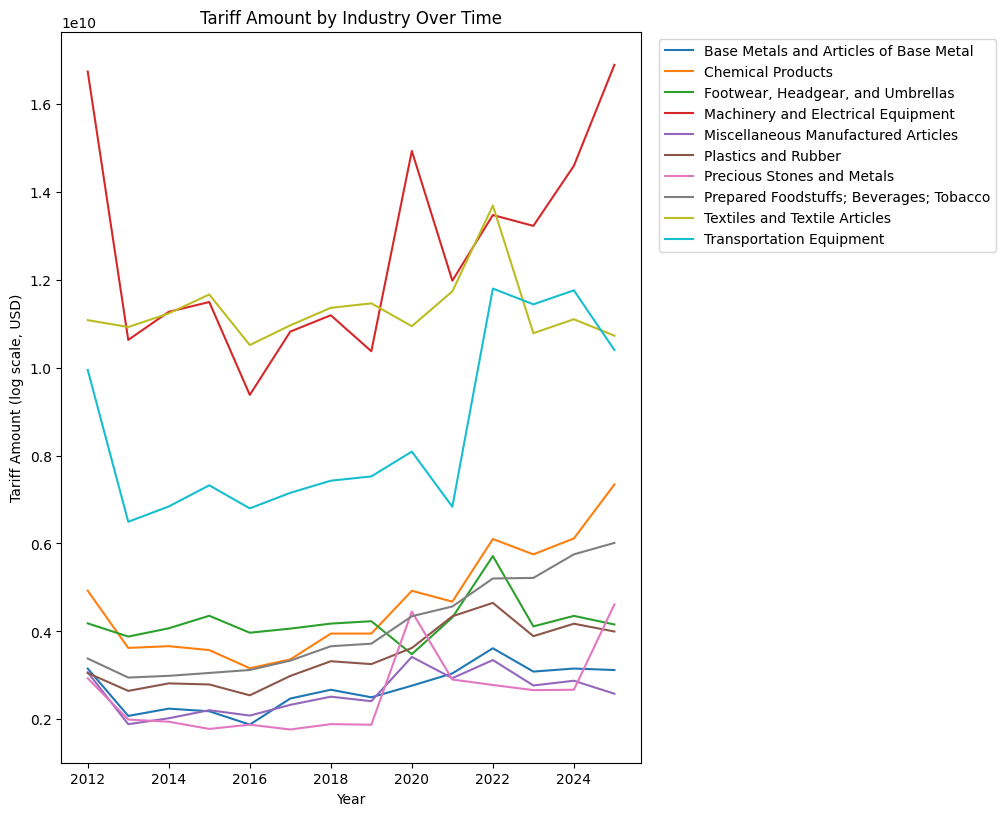

In [4]:
#plot industry tariff amount trends 

#mask for top 10 tariff amounts 
top_industries = (
    time_series_df
    .groupby("industry")['tariff_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)


filtered = time_series_df[time_series_df['industry'].isin(top_industries)]

industry_ts = (
    filtered
    .groupby(["year", "industry"])["tariff_amount"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,8))
for industry in industry_ts["industry"].unique():
    
    subset = industry_ts[industry_ts["industry"] == industry]
    
    plt.plot(subset["year"], subset["tariff_amount"], label=industry)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()

plt.xlabel("Year")
plt.ylabel("Tariff Amount (log scale, USD)")
plt.title("Tariff Amount by Industry Over Time")


plt.show()

**Observations:**

* Machinery and Electrical Equipment dominate the total tariff amount with spikes in 2012 and post 2024 showing sensitivity to trade policy.
* Textiles and Chemical Products show most directionally consistent trends. With Textiles remaining mostly consistent and Chemicals steadily climb. Implying more predictable tariffs on these sectors.

##### Import Value by Industry (2012 - 2025)

Text(0.5, 1.0, 'Import Value by Industry Over Time')

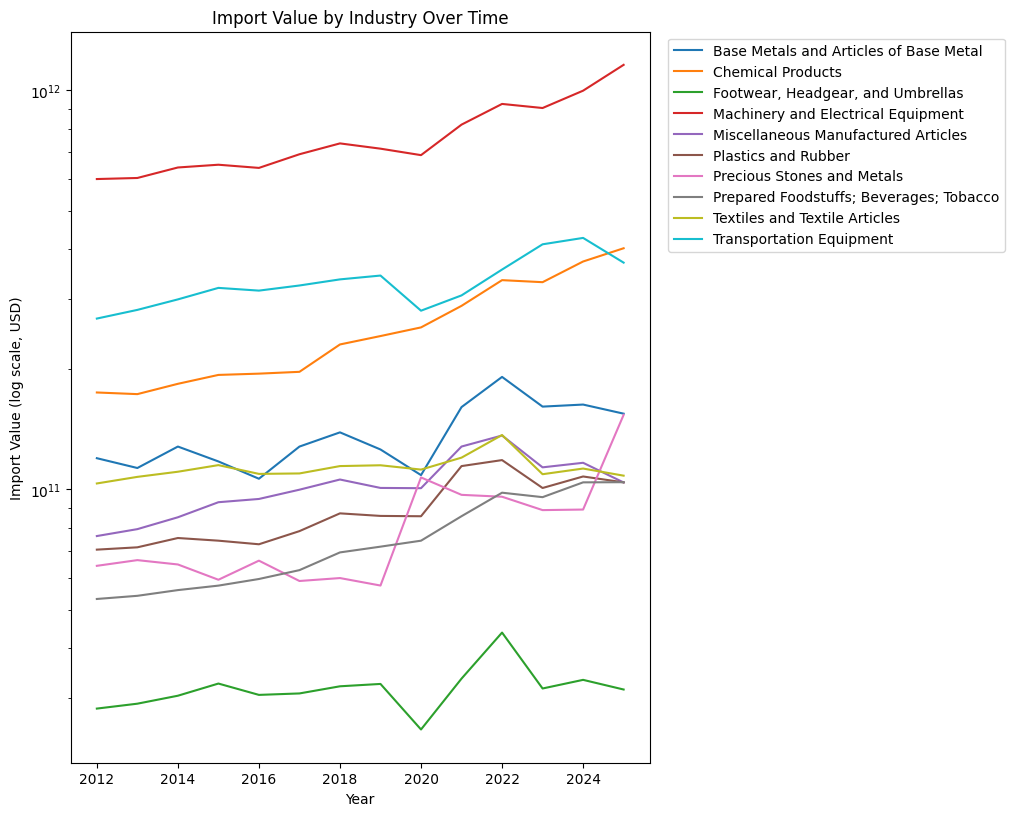

In [5]:
industry_ts = (
    filtered
    .groupby(["year", "industry"])["import_value"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,8))
for industry in industry_ts["industry"].unique():
    
    subset = industry_ts[industry_ts["industry"] == industry]
    
    plt.plot(subset["year"], subset["import_value"], label=industry)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("Import Value (log scale, USD)")
plt.title("Import Value by Industry Over Time")


**Observations:** 

* Machinery and Electrical Equipment is the dominant import category showing how regardless of tariffs there will continue to be import demand.
* There has been overall consistent growth in total import over most industries.
* There is a disruption around 2019-2020 which is most likely driven by COVID-19, while post 2020 there is consistent recovery.

##### Tariff Share by Industry (2012 - 2025)

In [6]:
#calculate share of total tariffs
time_series_df["tariff_share"] = (
    time_series_df["tariff_amount"] /
    time_series_df.groupby("year")["tariff_amount"].transform("sum")
)

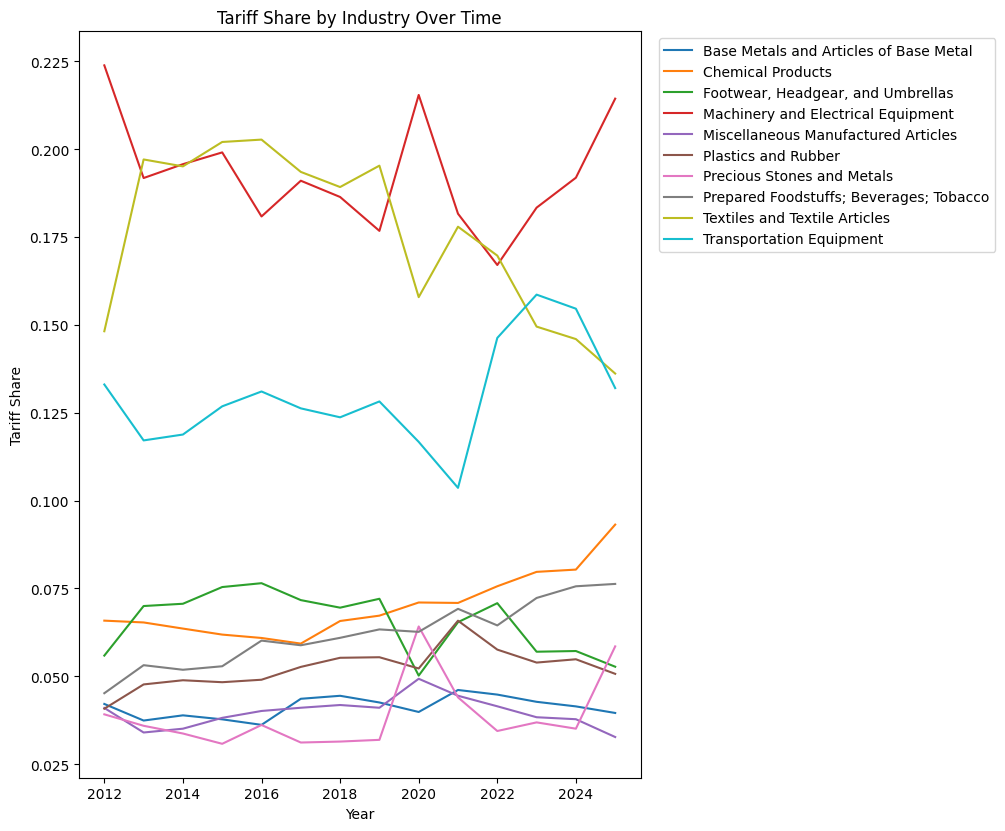

In [7]:
#plot industry tariff amount trends 

#mask for top 10 tariff amounts 
top_industries_share = (
    time_series_df
    .groupby("industry")['tariff_share']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)


filtered_share = time_series_df[time_series_df['industry'].isin(top_industries_share)]

industry_share_ts = (
    filtered_share
    .groupby(["year", "industry"])["tariff_share"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,8))
for industry in industry_share_ts["industry"].unique():
    
    subset = industry_share_ts[industry_share_ts["industry"] == industry]
    
    plt.plot(subset["year"], subset["tariff_share"], label=industry)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.xlabel("Year")
plt.ylabel("Tariff Share")
plt.title("Tariff Share by Industry Over Time")


plt.show()

**Observations:** 

* Machinery and Electrical Equipment once again dominated throughout the years on this chart making up around 20% of all tariff share. 
* Textile tariff share has been declining since its peak in 2016, while Chemical Products have shown an opposite trend, showing steady growth since 2017.
* Majority of industries cluster around 4-8% indicating how tariff changes affect larger industries.

### Conclusions

* High tariffs have not stopped import growth, as Machinery and Electrical Equipment has held both the highest tariff share and the highest import rate. This suggests that even with new tariff policy and increased tariffs the demand remains intact.
* Based off observations changes in trade volume and demand have had a greater impact on tariff amount than changes in tariff rates themselves.
* Tariff amounts are concentrated with the top three industries accounting for 50% of the total tariff share.